In [1]:
import utils
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

2026-03-04 22:21:15.285292: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 22:21:15.775499: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-04 22:21:26.811114: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
other = 'Other car'

In [3]:
columns = ("gate1", "gate2", "lighting")
(train_x, train_y), (val_x, val_y), (test_x, test_y) = utils.read_andre_data()
xs = [train_x, val_x, test_x]
ys = [train_y, val_y, test_y]

Correction complete!
 - Files found as-is: 2078
 - Extensions corrected: 955
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 437
 - Extensions corrected: 213
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 449
 - Extensions corrected: 202
 - Still missing (not found): 0


In [4]:
print(train_x.shape)
print(train_y.shape)
print(val_x.shape)
print(val_y.shape)
print(test_x.shape)
print(test_y.shape)

(3033, 300, 300, 3)
(3033, 10)
(650, 300, 300, 3)
(650, 10)
(651, 300, 300, 3)
(651, 10)


In [5]:
columns = ['model', 'lighting']


strata_train = train_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_val = val_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

strata_test = test_y[list(columns)]\
    .fillna('')\
    .astype(str)\
    .agg('-'.join, axis=1).value_counts().sort_values()

comparison = pd.DataFrame({
    'treningssett': strata_train,
    'valideringssett': strata_val,
    'testsett': strata_test
})

comparison = comparison.fillna(0).astype(int)

comparison = comparison.sort_values(by='testsett')

print(comparison)

                    treningssett  valideringssett  testsett
S 2012–2015-Dark               7                1         1
S 2012–2015-Medium             7                2         2
S 2016–nå-Dark                11                2         2
S 2016–nå-Medium              12                2         3
X-Medium                      17                4         4
X-Dark                        30                7         6
Y 2025-nå-Light               46               10        10
3 2024–nå-Dark                55               12        12
3 2024–nå-Medium              54               12        12
Other car-Medium              58               13        13
S 2012–2015-Light             62               13        13
3 2024–nå-Light               63               13        13
Other car-Dark                67               14        14
S 2016–nå-Light               72               15        15
3 2017–2023-Medium            69               15        15
3 2017–2023-Dark              72        

In [6]:
columns = ['model']

train_key = train_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)
test_key = test_y[list(columns)].fillna('').astype(str).agg('-'.join, axis=1)

train_lighting = pd.crosstab(train_key, train_y['lighting'])
test_lighting = pd.crosstab(test_key, test_y['lighting'])

desired_order = ['Light', 'Medium', 'Dark']

all_indices = sorted(set(train_lighting.index) | set(test_lighting.index))
comparison = pd.DataFrame(index=all_indices)

for light in desired_order:
    tr_val = train_lighting[light] if light in train_lighting.columns else pd.Series(0, index=comparison.index)
    te_val = test_lighting[light] if light in test_lighting.columns else pd.Series(0, index=comparison.index)

    tr = tr_val.reindex(comparison.index, fill_value=0)
    te = te_val.reindex(comparison.index, fill_value=0)
    
    comparison[light] = tr.astype(str) + "/" + te.astype(str)

print(comparison)

                Light  Medium    Dark
3 2017–2023    100/21   69/15   72/15
3 2024–nå       63/13   54/12   55/12
Other car    1312/282   58/13   67/14
S 2012–2015     62/13     7/2     7/1
S 2016–nå       72/15    12/3    11/2
X              138/30    17/4    30/6
Y 2020–2024    273/58  163/35  164/35
Y 2025-nå       46/10   95/21   86/19


In [7]:
i = 0

color                            Red
lighting                       Light
model                    S 2012–2015
source                      external
year                       2012–2015
lvl1                           Tesla
lvl2                     S 2012–2015
strat_key    Tesla|S 2012–2015|Light
gate1                              1
gate2                              2
Name: 0, dtype: object


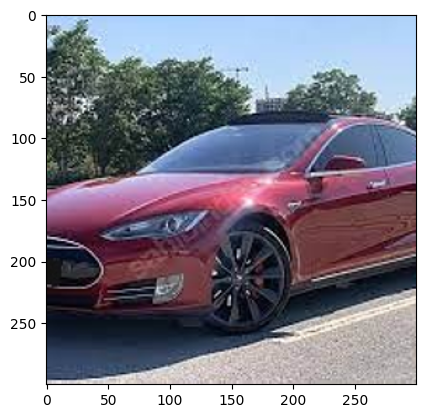

In [8]:
print(train_y.iloc[i])
plt.imshow(train_x[i])
plt.show()
i += 1

In [9]:
train_y_new = train_y["model"]
val_y_new = val_y["model"]
test_y_new = test_y["model"]
def t(x):
    if x == 'Other car':
        return 1
    return 0

vt = np.vectorize(t)

train_y_new = vt(train_y_new)
val_y_new = vt(val_y_new)
test_y_new = vt(test_y_new)

def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(inputs)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)
    return keras.Model(inputs, outputs) 

functional_model = make_model(train_x[0].shape, 1)

epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

functional_model.fit(
    train_x,
    train_y_new,
    epochs=epochs,
    validation_data=(val_x, val_y_new)
)

I0000 00:00:1772659339.539243   17648 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/5


2026-03-04 22:22:25.765557: I external/local_xla/xla/service/service.cc:163] XLA service 0x79a624006fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 22:22:25.765593: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-04 22:22:25.835521: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-04 22:22:26.075169: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


 7/95 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5349 - loss: 1.0226

I0000 00:00:1772659352.179774   18028 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.6736 - loss: 0.6458 - val_accuracy: 0.7692 - val_loss: 0.5256
Epoch 2/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8035 - loss: 0.4530 - val_accuracy: 0.8031 - val_loss: 0.4467
Epoch 3/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8500 - loss: 0.3631 - val_accuracy: 0.8077 - val_loss: 0.4273
Epoch 4/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8922 - loss: 0.2748 - val_accuracy: 0.8169 - val_loss: 0.4010
Epoch 5/5
95/95 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9285 - loss: 0.2099 - val_accuracy: 0.8077 - val_loss: 0.4256


In [10]:
functional_model.evaluate(test_x, test_y_new)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8141 - loss: 0.4292


[0.4291820526123047, 0.8141320943832397]

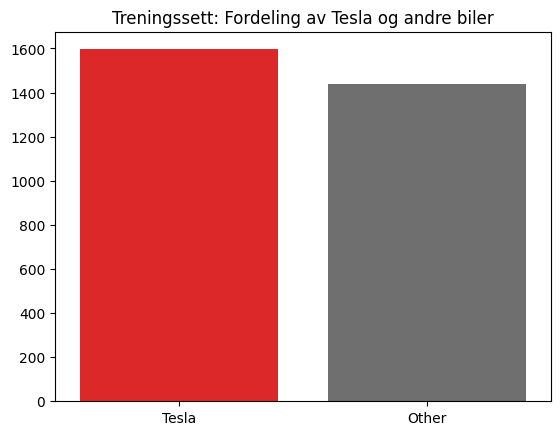

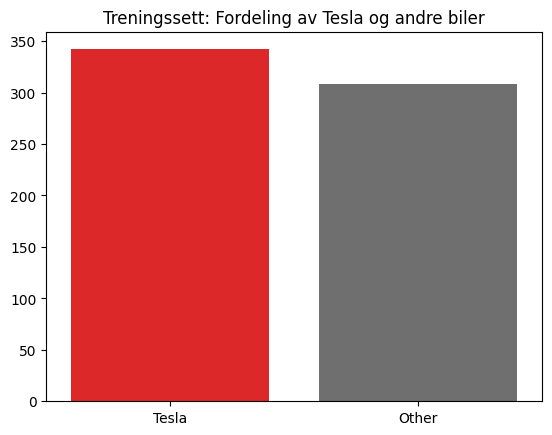

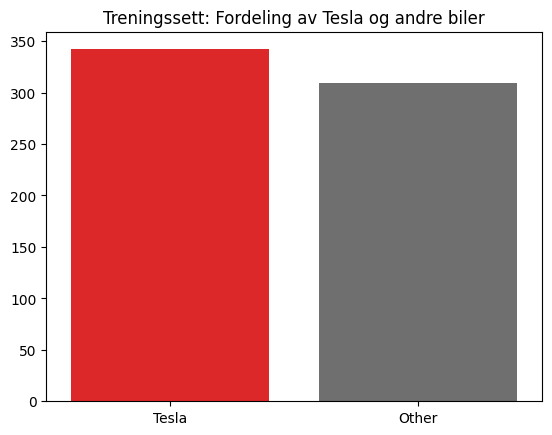

In [11]:
for df in ys:
    other = 'Other car'

    names = ['Tesla', 'Other']
    counts = [len(df[df['model'] != other]), len(df[df['model'] == other])]

    plot = sns.barplot(x=names, y=counts, hue=names, palette=["#fa0a0a", "#6f6f6f"], legend=False)
    plot.set_title(f'Treningssett: Fordeling av Tesla og andre biler')
    plt.show()  



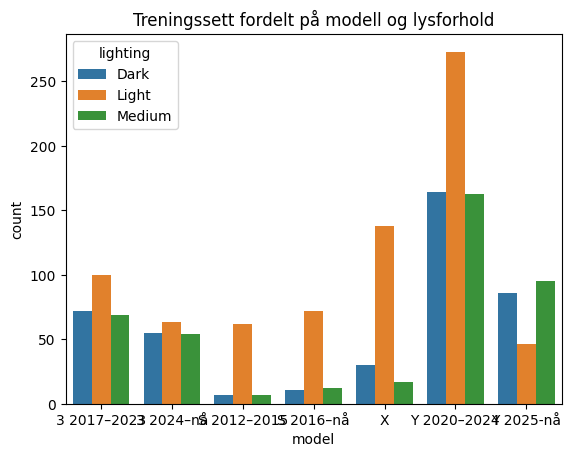

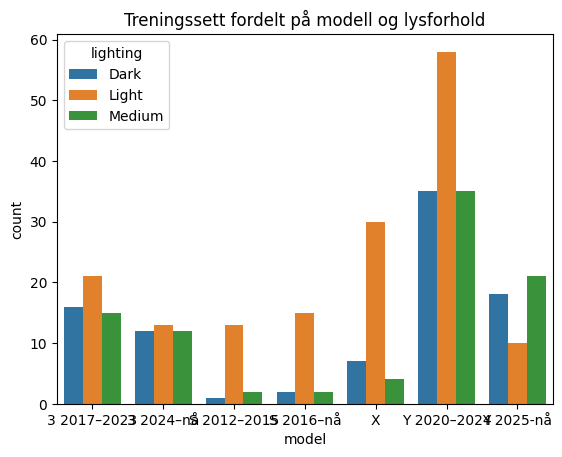

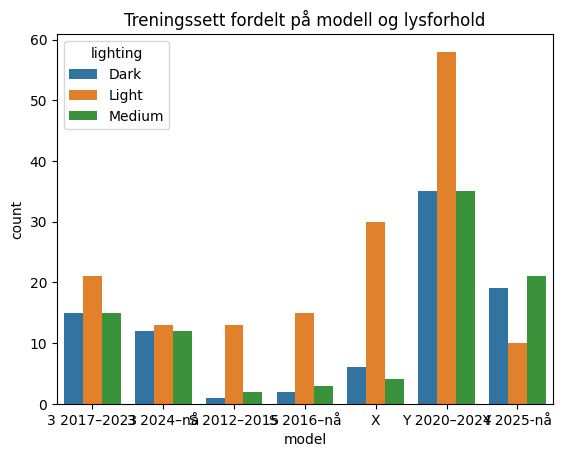

In [12]:
for df in ys:
    other = 'Other car'
    tesla = df[df['model'] != other].sort_values(by="model").sort_values(by="lighting", kind='stable')

    sns.countplot(data=tesla, x="model", hue="lighting").set_title("Treningssett fordelt på modell og lysforhold")
    plt.show()



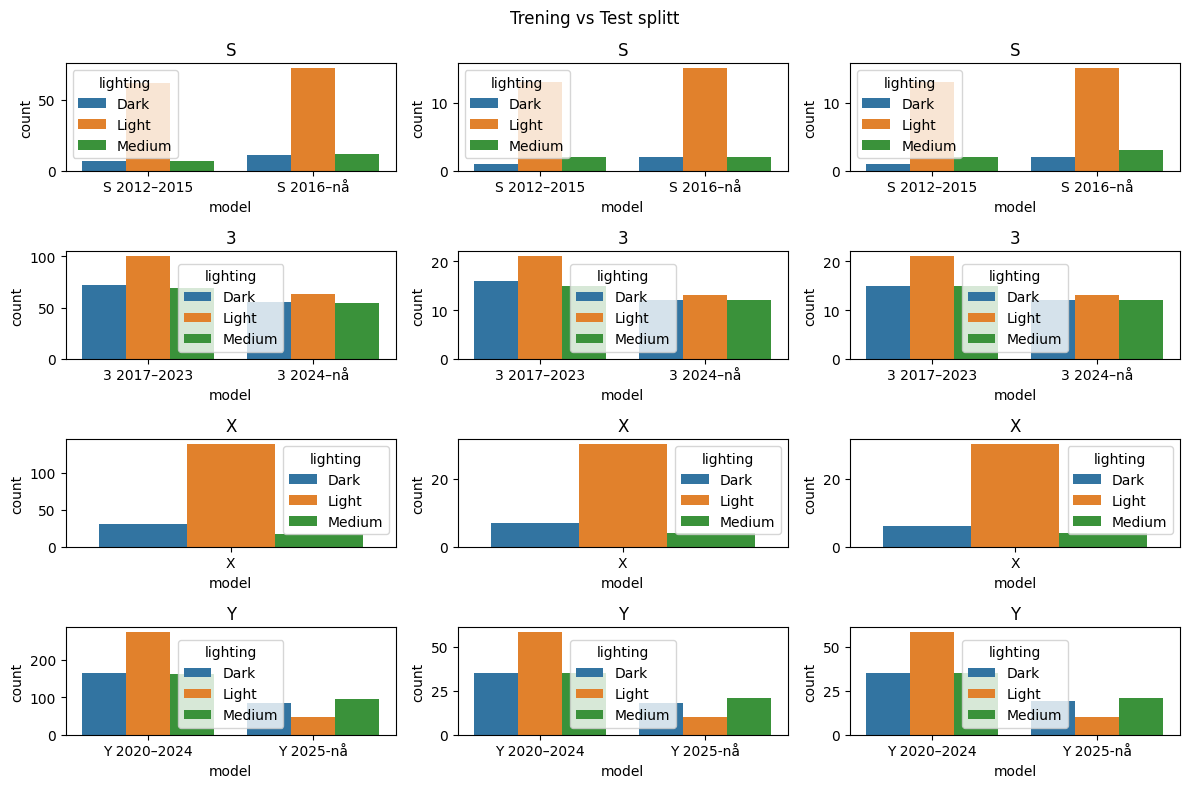

In [13]:
train_y_split = [
    train_y[train_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    train_y[train_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

val_y_split =[
    val_y[val_y['model'].str.contains('S')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('3')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('X')].sort_values('lighting').sort_values('model', kind='stable'),
    val_y[val_y['model'].str.contains('Y')].sort_values('lighting').sort_values('model', kind='stable')
]

test_y_split = [
    test_y[test_y['model'].str.contains('S')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('3')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('X')].sort_values('lighting').sort_values('lighting', kind='stable'),
    test_y[test_y['model'].str.contains('Y')].sort_values('lighting').sort_values('lighting', kind='stable')
]

models = ["S", "3", "X", "Y"]
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
fig.suptitle(f'Trening vs Test splitt')
for i in range(0,2):
    for j in range(0,2):
        sns.countplot(x='model', data=train_y_split[i*2 + j], ax=axes[i*2+j,0], hue='lighting')
        axes[i*2+j,0].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=val_y_split[i*2 + j], ax=axes[i*2+j,1], hue='lighting')
        axes[i*2+j,1].title.set_text(models[i*2 + j])
        sns.countplot(x='model', data=test_y_split[i*2 + j], ax=axes[i*2+j,2], hue='lighting')
        axes[i*2+j,2].title.set_text(models[i*2 + j])

plt.tight_layout()
plt.show()

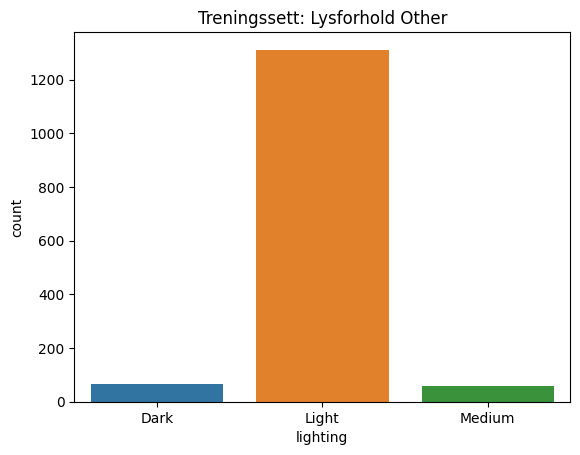

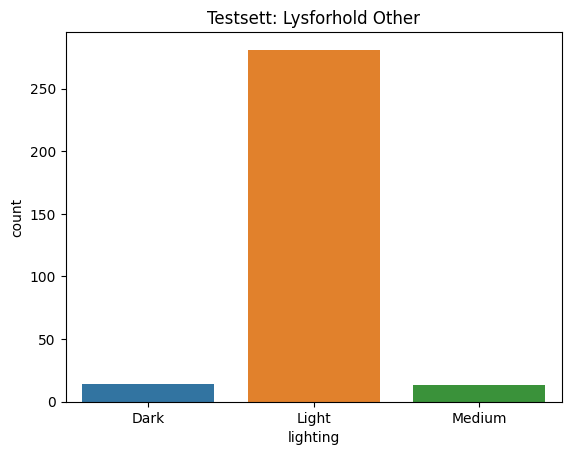

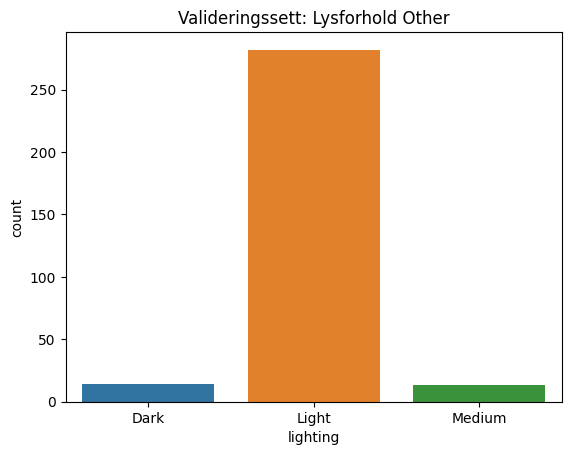

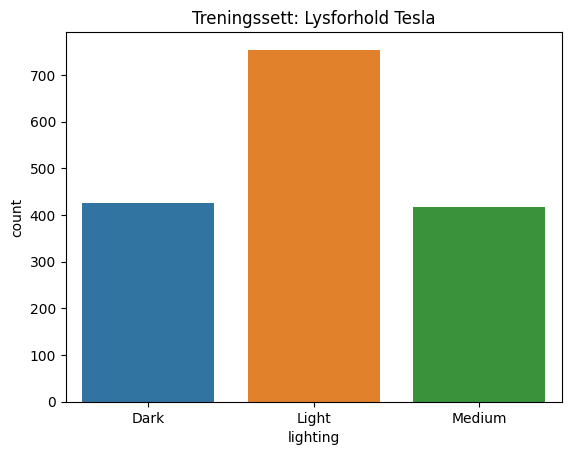

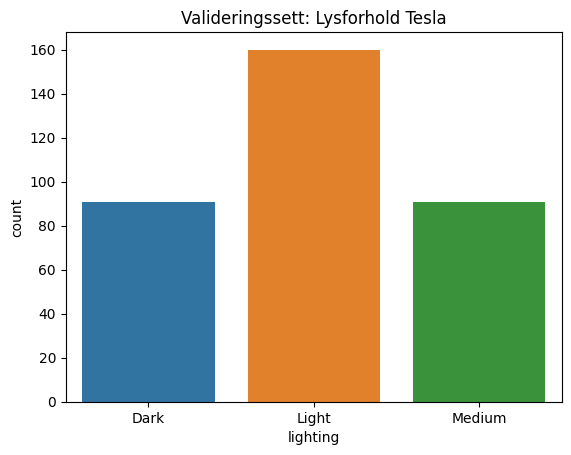

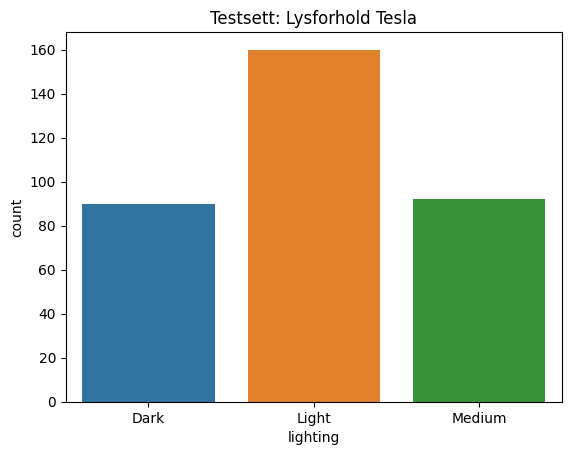

: 

In [ ]:
df = train_y[train_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Other')
plt.show()

df = val_y[val_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Other')
plt.show()

df = test_y[test_y["model"] == other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Other')
plt.show()

df = train_y[train_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Treningssett: Lysforhold Tesla')
plt.show()

df = val_y[val_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Valideringssett: Lysforhold Tesla')
plt.show()

df = test_y[test_y["model"] != other].sort_values(by="lighting")
plot = sns.countplot(data=df, x='lighting', hue='lighting')
plot.set_title(f'Testsett: Lysforhold Tesla')
plt.show()

